In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

import importlib

### Single-particle Density

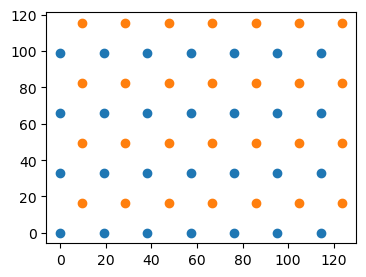

(169, 28) (169, 28)


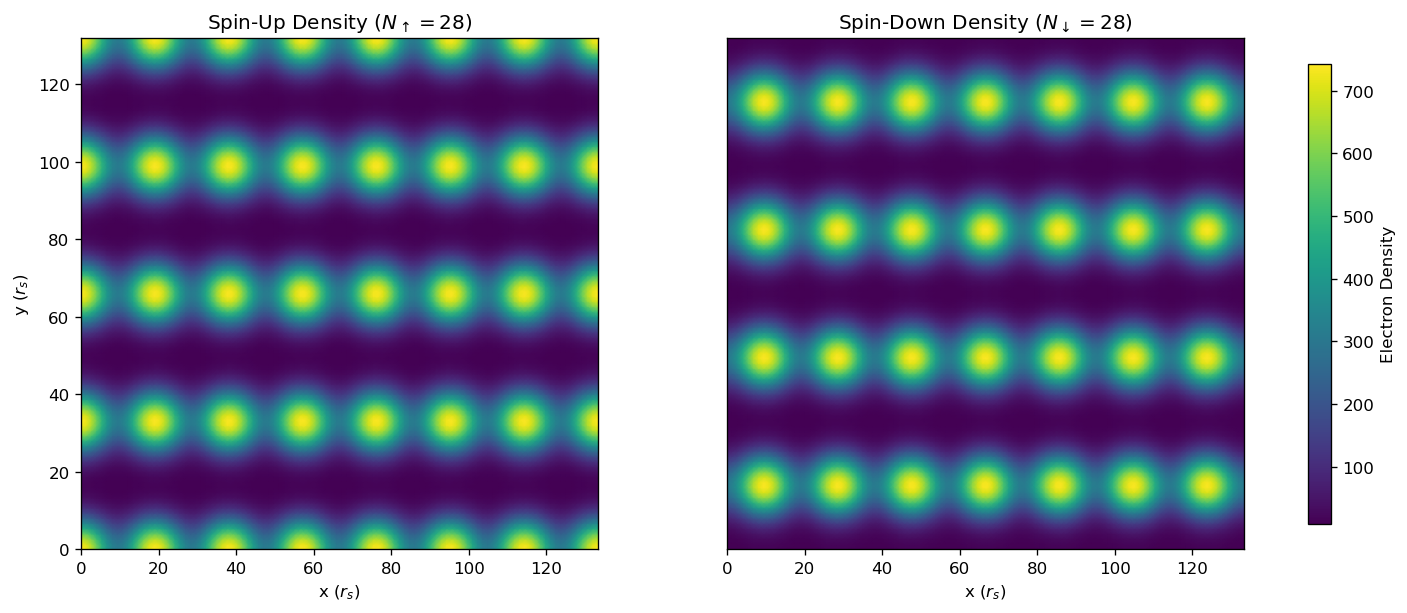

In [59]:
importlib.reload(wavefunctions)
importlib.reload(trajectory)

r_ws = 10
N = 56
dim = 2
numKpts = 169

NUp = N // 2
NDown = N - NUp
spins = ( NUp , NDown )

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)
kpoints = wavefunctions.genKpoints(numKpts, lattice, dim)

rj = trajectory.generateStripedAFM(
    spins, lattice, dim, gridShape=(7,4)
)

(rjUp,rjDown) = rj[:spins[0]], rj[spins[0]:]

plt.figure(figsize=(4,3))
plt.scatter(rjUp[:,0], rjUp[:,1])
plt.scatter(rjDown[:,0], rjDown[:,1])
plt.show()

alpha = 1 / r_ws ** 2.0

upCoeffs = wavefunctions.generateGaussianMPCoeffs(kpoints, rjUp, alpha)
downCoeffs = wavefunctions.generateGaussianMPCoeffs(kpoints, rjDown, alpha)

print(upCoeffs.shape, downCoeffs.shape)

Nk = kpoints.shape[0]
cos = jnp.zeros(Nk).at[0].set(1.0)
cos = cos.at[jnp.arange(1, Nk, 2)].set(1.0)
cos_switch = cos
sin_switch = 1.0 - cos

def eval_basis_at_point(r):
    dot_vals = jnp.dot(kpoints, r)
    terms = cos_switch * jnp.cos(dot_vals) + sin_switch * jnp.sin(-dot_vals)
    return terms

# 3. Generate Grid
n_grid = 100
u = jnp.linspace(0, 1, n_grid)
v = jnp.linspace(0, 1, n_grid)
uu, vv = jnp.meshgrid(u, v) 
flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
flat_real = flat_frac @ lattice 

# 4. Compute Densities
# Evaluate basis: (N_grid, N_k)
basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 

# Calculate Up Orbitals: (N_grid, N_k) @ (N_k, N_up) -> (N_grid, N_up)
orbitals_up = jnp.dot(basis_vals, upCoeffs)
# Calculate Down Orbitals: (N_grid, N_k) @ (N_k, N_down) -> (N_grid, N_down)
orbitals_down = jnp.dot(basis_vals, downCoeffs)

# Sum squares to get density
rho_up = jnp.sum(orbitals_up**2, axis=1).reshape(n_grid, n_grid)
rho_down = jnp.sum(orbitals_down**2, axis=1).reshape(n_grid, n_grid)

# 5. Plot Side-by-Side
# Grid coordinates for plotting
grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
X_plot = grid_real[:, :, 0]
Y_plot = grid_real[:, :, 1]

# Determine global min/max for shared colorbar
vmin = min(rho_up.min(), rho_down.min())
vmax = max(rho_up.max(), rho_down.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)

# Plot Up
im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f"Spin-Up Density ($N_{{\\uparrow}}={NUp}$)")
axes[0].set_aspect('equal')
axes[0].set_xlabel("x ($r_s$)")
axes[0].set_ylabel("y ($r_s$)")

# Plot Down
im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f"Spin-Down Density ($N_{{\\downarrow}}={NDown}$)")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x ($r_s$)")
axes[1].set_yticks([]) # Hide Y ticks for the second plot

# Shared Colorbar
fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)
plt.show()